<a href="https://colab.research.google.com/github/Omsai-2000/Exploratory-Data-Analysis/blob/main/Decision_tree_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [20]:
diabetes_df=pd.read_csv('diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
diabetes_df.shape

(768, 9)

In [22]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


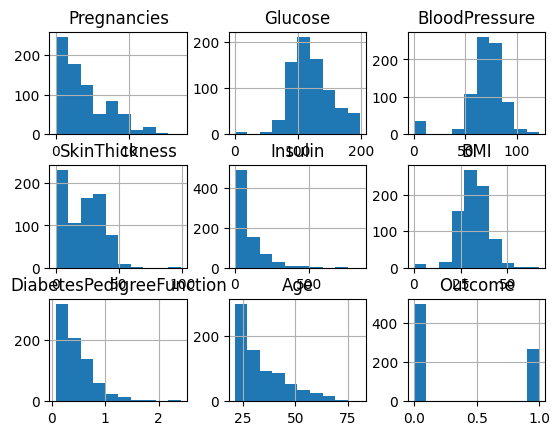

In [25]:
diabetes_df.hist()
plt.show()

In [31]:
x=diabetes_df.drop('Outcome',axis=1)
y=diabetes_df['Outcome']

In [32]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [33]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

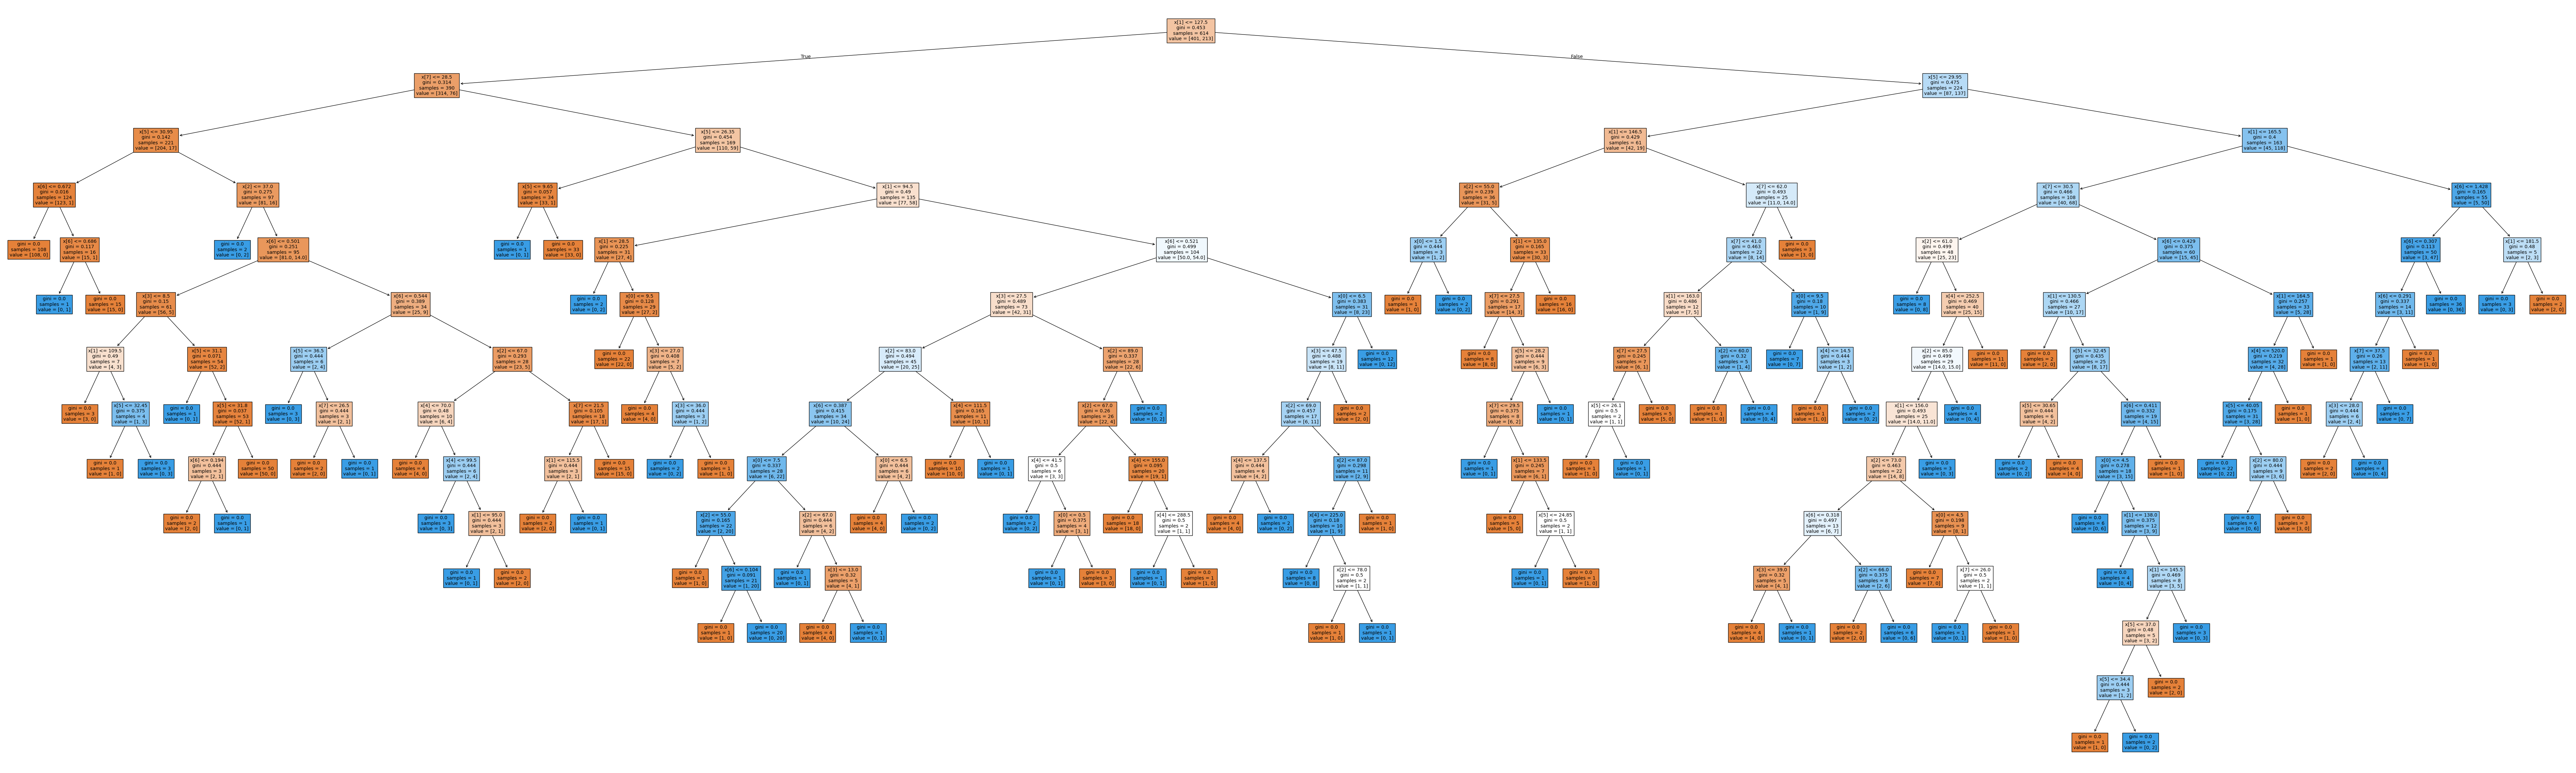

In [51]:
from sklearn import tree
fig=plt.figure(figsize=(100,30))
tree.plot_tree(dtc,filled=True)
plt.show()

In [52]:
dtc2=DecisionTreeClassifier(criterion='entropy')
dtc2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

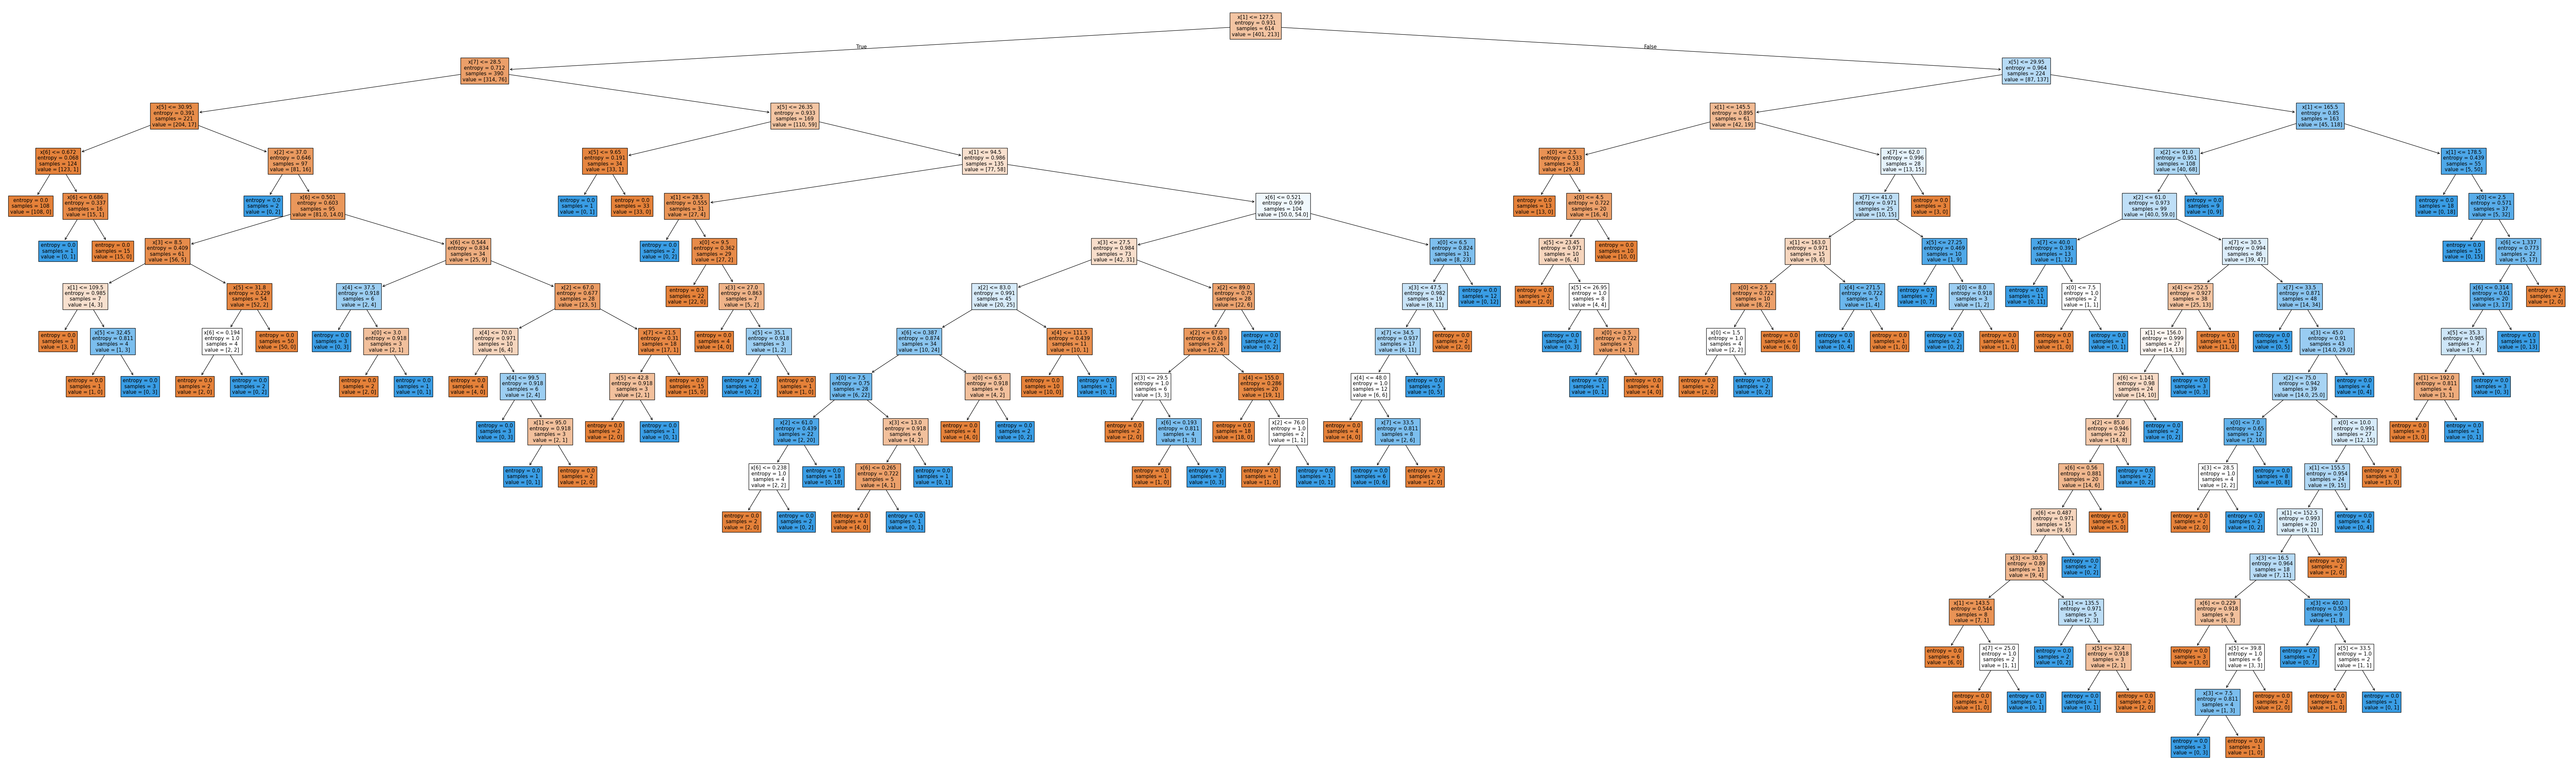

In [53]:
fig2=plt.figure(figsize=(100,30))
tree.plot_tree(dtc2,filled=True)
plt.show()

In [54]:
dtc.feature_importances_

array([0.04976234, 0.32002697, 0.15103776, 0.05802138, 0.06948766,
       0.16231365, 0.08390476, 0.10544548])

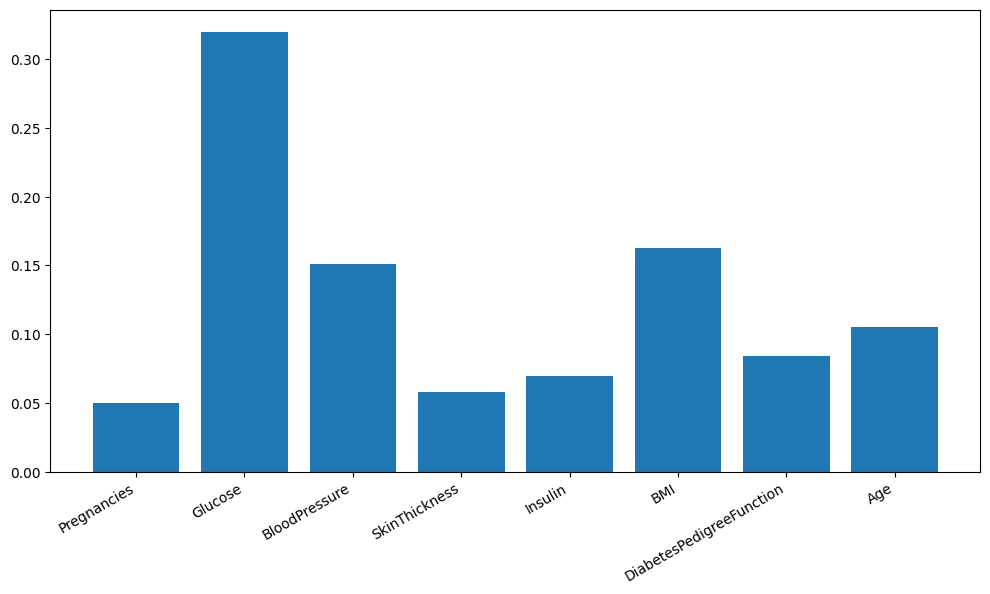

In [62]:
plt.figure(figsize=(12,6))
plt.bar(x.columns, dtc.feature_importances_)
plt.xticks(rotation=30, ha='right')
plt.show()

In [58]:
y_pred=dtc.predict(x_test)

In [60]:
from matplotlib import cm
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
cm

array([[76, 23],
       [14, 41]])

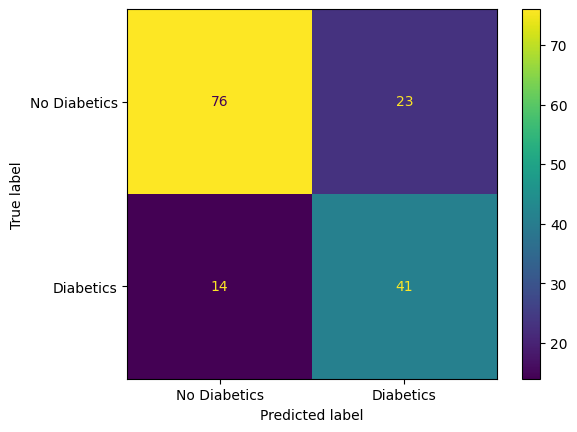

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
display_cm=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Diabetics', 'Diabetics'])
display_cm.plot()
plt.show()

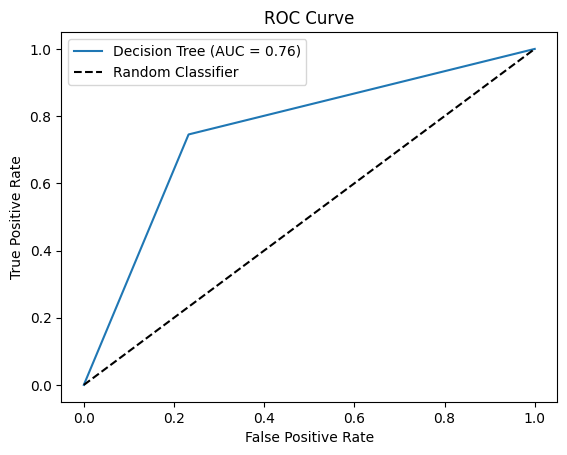

In [78]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_prob = dtc.predict_proba(x_test)[:, 1]
#plt.figure(figsize=(10,8))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()